Continuous candidate from FOC:
Initial guess used: [0.06   0.0375]
f1* = 0.099949901714
f2* = 0.085458873160
EJ1 = 115.470064975625
EJ2 = 100.322565971893
p0, p1, p2 = 0.073269630919, 0.808161500623, 0.118568868458

Region checks:
D12 < 0: True
gamma10 = 0.032192599820
gamma20 = 0.029307852368
gamma12 = 0.076735399751
0 < gamma12 < gamma_bar: True
gamma12 >= gamma10: True
gamma20 <= gamma12: True

Simulation results:
 run  f1_init  f2_init  f1_sim  f2_sim        EJ1        EJ2       p0       p1       p2  dist_to_candidate  iterations
   1   0.0375   0.0375  0.0999  0.0854 115.455671 100.320772 0.073220 0.808068 0.118712           0.000077           6
   2   0.0375   0.0600  0.0999  0.0854 115.455671 100.320772 0.073220 0.808068 0.118712           0.000077           5
   3   0.0375   0.0825  0.0999  0.0854 115.455671 100.320772 0.073220 0.808068 0.118712           0.000077           4
   4   0.0375   0.1050  0.1000  0.0855 115.480119 100.324365 0.073304 0.808026 0.118670           0.000

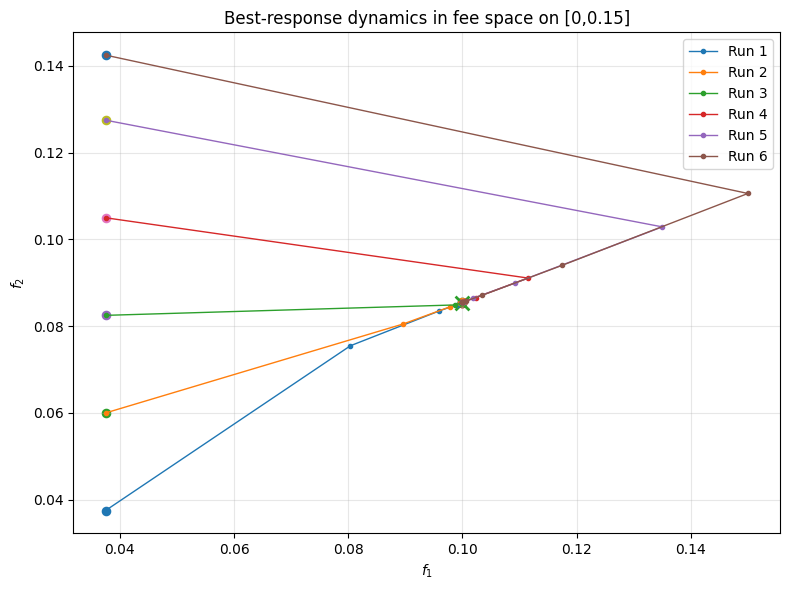

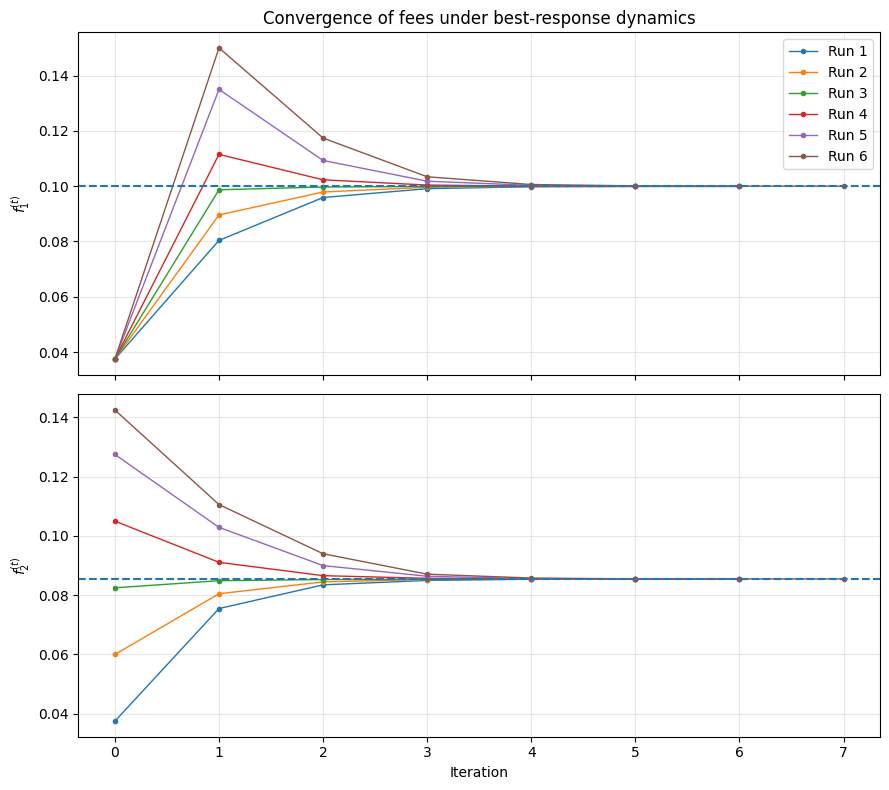


Comparison with the continuous FOC candidate:
Candidate: (f1*, f2*) = (0.099950, 0.085459)
Run 1: simulated limit = (0.099900, 0.085400), distance to candidate = 7.717662e-05, p = (0.073220, 0.808068, 0.118712)
Run 2: simulated limit = (0.099900, 0.085400), distance to candidate = 7.717662e-05, p = (0.073220, 0.808068, 0.118712)
Run 3: simulated limit = (0.099900, 0.085400), distance to candidate = 7.717662e-05, p = (0.073220, 0.808068, 0.118712)
Run 4: simulated limit = (0.100000, 0.085500), distance to candidate = 6.481709e-05, p = (0.073304, 0.808026, 0.118670)
Run 5: simulated limit = (0.100000, 0.085500), distance to candidate = 6.481709e-05, p = (0.073304, 0.808026, 0.118670)
Run 6: simulated limit = (0.100000, 0.085500), distance to candidate = 6.481709e-05, p = (0.073304, 0.808026, 0.118670)


In [1]:
## VERSION FINAL GENERIQUE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root

# =========================================================
# GENERIC FOC-ONLY FEE GAME SOLVER
# =========================================================
# This script is generic with respect to the initial parameters:
#   delta1, delta2, eta1, eta2, f_max
#
# It automatically:
#   1) builds threshold functions
#   2) defines participation probabilities
#   3) builds the FOC system in the targeted interior region
#   4) generates several initial guesses in (0, f_max]
#   5) solves the FOC numerically
#   6) simulates best-response dynamics on the same fee domain to see if it converges to the numerical solution
# =========================================================


# ---------------------------------------------------------
# 1. USER PARAMETERS
# ---------------------------------------------------------
b = 3.125
gamma_bar = 0.4
Lambda = 100.0

delta1 = 0.008   ################## A CHANGER
delta2 = 0.08    ################## A CHANGER

eta1 = 0.01      ################## A CHANGER
eta2 = 0.001     ################# A CHANGER

y1 = 100.0
y2 = 100.0

# upper bound for admissible fees
f_max = 0.15      ################### A CHANGER

# simulation grid density
n_grid = 1501


# ---------------------------------------------------------
# 2. Thresholds
# ---------------------------------------------------------
def gamma_10(f1):
    return f1 / (b * (1.0 - delta1 * (1.0 - f1) ** 2))


def gamma_20(f2):
    return f2 / (b * (1.0 - delta2 * (1.0 - f2) ** 2))
        # ---------------------------------------------------------
        # gamma_20(f2)
        #
        # Threshold where pool 2 becomes as attractive as solo mining.
        #
        # gamma_20 solves:
        #     s2(gamma) = s0(gamma)
        #
        # Analytical formula:
        #
        # gamma_20(f2) = f2 / ( b * (1 - delta2 * (1 - f2)^2 ) )
        #
        # It represents the level of risk aversion above which
        # a miner prefers pool 2 to solo mining.
        # ---------------------------------------------------------



def D12(f1, f2):
    return delta1 * (1.0 - f1) ** 2 - delta2 * (1.0 - f2) ** 2


def D21(f1, f2):
    return -D12(f1, f2)


def gamma_12(f1, f2):
    d = D12(f1, f2)
    if np.isclose(d, 0.0):
        return np.nan
    return (f2 - f1) / (b * d)


def gamma_21(f1, f2):
    d = D21(f1, f2)
    if np.isclose(d, 0.0):
        return np.nan
    return (f1 - f2) / (b * d)
        # ---------------------------------------------------------
        # Threshold between pool 1 and pool 2
        #
        # gamma_12 solves:
        #
        #     s1(gamma) = s2(gamma)
        #
        # Analytical formula:
        #
        #     gamma_12 = (f2 - f1) / ( b * D12 )
        #
        # where
        #
        #     D12 = delta1 (1 - f1)^2 - delta2 (1 - f2)^2
        #
        # Important identity:
        #
        #     gamma_21 = gamma_12
        #
        # because
        #
        #     D21 = -D12
        #
        # and
        #
        #     gamma_21 = (f1 - f2) / ( b * D21 )
        #               = (f1 - f2) / ( b * (-D12) )
        #               = (f2 - f1) / ( b * D12 )
        #               = gamma_12
        #
        # Therefore the code only needs one function (gamma_12)
        # even when computing the participation probability of pool 2.
        # ---------------------------------------------------------



# ---------------------------------------------------------
# 3. Participation probabilities
# ---------------------------------------------------------
def p1(f1, f2):
    d = D12(f1, f2)
    g10 = gamma_10(f1)

    if d > 0:
        g12 = gamma_12(f1, f2)
        lower = max(0.0, g10)
        upper = min(gamma_bar, g12)
        return max(0.0, upper - lower) / gamma_bar

    if d < 0:
        g12 = gamma_12(f1, f2)
        lower = max(0.0, g10, g12)
        return max(0.0, gamma_bar - lower) / gamma_bar

    if f1 <= f2:
        return max(0.0, gamma_bar - max(0.0, g10)) / gamma_bar
    return 0.0


def p2(f1, f2):
    d = D21(f1, f2)
    g20 = gamma_20(f2)

    if d > 0:
        g21 = gamma_21(f1, f2)
        lower = max(0.0, g20)
        upper = min(gamma_bar, g21)
        return max(0.0, upper - lower) / gamma_bar

    if d < 0:
        g21 = gamma_21(f1, f2)
        lower = max(0.0, g20, g21)
        return max(0.0, gamma_bar - lower) / gamma_bar

    if f2 <= f1:
        return max(0.0, gamma_bar - max(0.0, g20)) / gamma_bar
    return 0.0


def p0(f1, f2):
    return max(0.0, 1.0 - p1(f1, f2) - p2(f1, f2))


# ---------------------------------------------------------
# 4. Expected hashrates
# ---------------------------------------------------------
def EH1(f1, f2):
    return Lambda * p1(f1, f2)


def EH2(f1, f2):
    return Lambda * p2(f1, f2)


def EH0(f1, f2):
    return Lambda * p0(f1, f2)


# ---------------------------------------------------------
# 5. Expected payoffs
# ---------------------------------------------------------
def B1(f1):
    return (
        f1 * (1.0 + delta1) - delta1
        - eta1 * b * (
            delta1 * (1.0 - f1) ** 2
            + (1.0 - (1.0 - f1) * delta1) ** 2
        )
    )


def B2(f2):
    return (
        f2 * (1.0 + delta2) - delta2
        - eta2 * b * (
            delta2 * (1.0 - f2) ** 2
            + (1.0 - (1.0 - f2) * delta2) ** 2
        )
    )


def EJ1(f1, f2):
    return y1 + EH1(f1, f2) * (b / (1.0 + delta1)) * B1(f1)


def EJ2(f1, f2):
    return y2 + EH2(f1, f2) * (b / (1.0 + delta2)) * B2(f2)


# ---------------------------------------------------------
# 6. Derivatives for FOC
# ---------------------------------------------------------
def D12_prime_f1(f1):
    return -2.0 * delta1 * (1.0 - f1)


def D12_prime_f2(f2):
    return 2.0 * delta2 * (1.0 - f2)


def gamma12_prime_f1(f1, f2):
    d = D12(f1, f2)
    if np.isclose(d, 0.0):
        return np.nan
    num = -(b * d) - (f2 - f1) * b * D12_prime_f1(f1)
    den = b ** 2 * d ** 2
    return num / den


def gamma12_prime_f2(f1, f2):   # derivative of gamma12 = derivative of gamma21
    d = D12(f1, f2)
    if np.isclose(d, 0.0):
        return np.nan
    num = (b * d) - (f2 - f1) * b * D12_prime_f2(f2)
    den = b ** 2 * d ** 2
    return num / den


def gamma20_prime_f2(f2):
    denom = b * (1.0 - delta2 * (1.0 - f2) ** 2)
    denom_prime = 2.0 * b * delta2 * (1.0 - f2)
    return (denom - f2 * denom_prime) / (denom ** 2)
        # ---------------------------------------------------------
        # Derivative of gamma_20 with respect to f2
        #
        # Recall:
        #
        # gamma_20(f2) = f2 / [ b * (1 - delta2 (1 - f2)^2) ]
        #
        # Let
        #
        # A(f2) = b * (1 - delta2 (1 - f2)^2)
        #
        # Then
        #
        # gamma_20(f2) = f2 / A(f2)
        #
        # Using the quotient rule:
        #
        # gamma_20'(f2) =
        #     ( A(f2) - f2 * A'(f2) ) / A(f2)^2
        #
        # This derivative is required when computing
        # the derivative of the participation probability p2.
        # ---------------------------------------------------------


def B1_prime(f1):
    inner_prime = (
        -2.0 * delta1 * (1.0 - f1)
        + 2.0 * delta1 * (1.0 - (1.0 - f1) * delta1)
    )
    return (1.0 + delta1) - eta1 * b * inner_prime


def B2_prime(f2):
    inner_prime = (
        -2.0 * delta2 * (1.0 - f2)
        + 2.0 * delta2 * (1.0 - (1.0 - f2) * delta2)
    )
    return (1.0 + delta2) - eta2 * b * inner_prime


# ---------------------------------------------------------
# 7. FOC system in the targeted interior region
# ---------------------------------------------------------
def foc_system(x):
    f1, f2 = x

    if not (0.0 < f1 <= f_max and 0.0 < f2 <= f_max):
        return np.array([1e6, 1e6])

    g10 = gamma_10(f1)
    g20 = gamma_20(f2)
    g12 = gamma_12(f1, f2)

    # targeted region:
    # D12 < 0, 0 < gamma12 < gamma_bar,
    # gamma12 >= gamma10, gamma20 <= gamma12
    if not (D12(f1, f2) < 0):
        return np.array([1e6, 1e6])
    if not np.isfinite(g12):
        return np.array([1e6, 1e6])
    if not (0.0 < g12 < gamma_bar):
        return np.array([1e6, 1e6])
    if not (g12 >= g10):
        return np.array([1e6, 1e6])
    if not (g20 <= g12):
        return np.array([1e6, 1e6])

    p1_reg = (gamma_bar - g12) / gamma_bar
    p2_reg = (g12 - g20) / gamma_bar
        # ---------------------------------------------------------
        # Participation probability of pool 2 in the interior region.
        #
        # In the region considered by the FOC solver we have:
        #
        #   D12 < 0
        #   gamma20 <= gamma12 <= gamma_bar
        #
        # The miners choosing pool 2 are those with
        #
        #   gamma in [ gamma20 , gamma12 ]
        #
        # Since gamma ~ Uniform[0, gamma_bar],
        #
        # p2 = (gamma12 - gamma20) / gamma_bar
        # ---------------------------------------------------------



    dp1_df1 = -gamma12_prime_f1(f1, f2) / gamma_bar
    dp2_df2 = (gamma12_prime_f2(f1, f2) - gamma20_prime_f2(f2)) / gamma_bar
        # ---------------------------------------------------------
        # Derivative of p2 with respect to f2.
        #
        # In this region:
        #
        # p2 = (gamma12 - gamma20) / gamma_bar
        #
        # Therefore
        #
        # dp2/df2 =
        #     (1/gamma_bar) *
        #     ( d gamma12 / df2  -  d gamma20 / df2 )
        #
        # This is why the code uses:
        #
        # gamma12_prime_f2(...)  and  gamma20_prime_f2(...)
        #
        # The derivative of gamma20 is necessary because
        # the solo vs pool 2 threshold depends on f2.
        # ---------------------------------------------------------



    F1 = dp1_df1 * B1(f1) + p1_reg * B1_prime(f1)
    F2 = dp2_df2 * B2(f2) + p2_reg * B2_prime(f2)
        # ---------------------------------------------------------
        # First-order condition for manager 2.
        #
        # Recall:
        #
        # E[J2] = y2 + Lambda * p2(f1,f2) * b/(1+delta2) * B2(f2)
        #
        # Differentiating with respect to f2 gives
        #
        # dE[J2]/df2 ∝
        #     dp2/df2 * B2(f2) + p2(f1,f2) * B2'(f2)
        #
        # The common factor Lambda * b/(1+delta2) is omitted
        # since it does not affect the root of the equation.
        # ---------------------------------------------------------

    return np.array([F1, F2])


# ---------------------------------------------------------
# 8. Automatic generation of initial guesses
# ---------------------------------------------------------
def build_initial_guesses(f_upper):
    """
    Build a generic set of initial guesses adapted to the chosen fee bound.
    """
    fracs = [0.25, 0.40, 0.55, 0.70, 0.85, 0.95]
    guesses = []

    for a in fracs:
        for b_ in fracs:
            guesses.append(np.array([a * f_upper, b_ * f_upper]))

    # remove duplicates
    unique = []
    for g in guesses:
        duplicate = False
        for h in unique:
            if np.allclose(g, h):
                duplicate = True
                break
        if not duplicate:
            unique.append(g)
    return unique


# ---------------------------------------------------------
# 9. Solve FOC from many starts
# ---------------------------------------------------------
def solve_foc_many_starts():
    initial_guesses = build_initial_guesses(f_max)
    sols = []

    for x0 in initial_guesses:
        trial = root(foc_system, x0)
        if not trial.success:
            continue

        f1_try, f2_try = trial.x
        if not (0.0 < f1_try <= f_max and 0.0 < f2_try <= f_max):
            continue

        # check region consistency again
        g10 = gamma_10(f1_try)
        g20 = gamma_20(f2_try)
        g12 = gamma_12(f1_try, f2_try)

        if not (D12(f1_try, f2_try) < 0):
            continue
        if not np.isfinite(g12):
            continue
        if not (0.0 < g12 < gamma_bar):
            continue
        if not (g12 >= g10):
            continue
        if not (g20 <= g12):
            continue

        # avoid duplicates
        duplicate = False
        for row in sols:
            if np.hypot(f1_try - row["f1"], f2_try - row["f2"]) < 1e-7:
                duplicate = True
                break
        if duplicate:
            continue

        sols.append({
            "f1": f1_try,
            "f2": f2_try,
            "x0": x0,
            "EJ1": EJ1(f1_try, f2_try),
            "EJ2": EJ2(f1_try, f2_try),
            "p0": p0(f1_try, f2_try),
            "p1": p1(f1_try, f2_try),
            "p2": p2(f1_try, f2_try),
        })

    return sols


solutions = solve_foc_many_starts()

if len(solutions) == 0:
    raise RuntimeError("No interior FOC solution found for the current parameter values.")

# choose the first one; could also choose by highest EJ1+EJ2
sol_pick = solutions[0]
f1_cont = sol_pick["f1"]
f2_cont = sol_pick["f2"]
x0_used = sol_pick["x0"]

print("Continuous candidate from FOC:")
print("Initial guess used:", x0_used)
print(f"f1* = {f1_cont:.12f}")
print(f"f2* = {f2_cont:.12f}")
print(f"EJ1 = {sol_pick['EJ1']:.12f}")
print(f"EJ2 = {sol_pick['EJ2']:.12f}")
print(f"p0, p1, p2 = {sol_pick['p0']:.12f}, {sol_pick['p1']:.12f}, {sol_pick['p2']:.12f}")

print("\nRegion checks:")
print(f"D12 < 0: {D12(f1_cont, f2_cont) < 0}")
print(f"gamma10 = {gamma_10(f1_cont):.12f}")
print(f"gamma20 = {gamma_20(f2_cont):.12f}")
print(f"gamma12 = {gamma_12(f1_cont, f2_cont):.12f}")
print(f"0 < gamma12 < gamma_bar: {0.0 < gamma_12(f1_cont, f2_cont) < gamma_bar}")
print(f"gamma12 >= gamma10: {gamma_12(f1_cont, f2_cont) >= gamma_10(f1_cont)}")
print(f"gamma20 <= gamma12: {gamma_20(f2_cont) <= gamma_12(f1_cont, f2_cont)}")


# ---------------------------------------------------------
# 10. Best-response simulation
# ---------------------------------------------------------
def best_response_1(f2, grid):
    vals = np.array([EJ1(f1, f2) for f1 in grid])
    idx = np.argmax(vals)
    return grid[idx], vals[idx]


def best_response_2(f1, grid):
    vals = np.array([EJ2(f1, f2) for f2 in grid])
    idx = np.argmax(vals)
    return grid[idx], vals[idx]


def simulate_best_response_dynamics(f1_init, f2_init, grid, max_iter=200, tol=1e-10):
    f1_path = [f1_init]
    f2_path = [f2_init]

    f1, f2 = f1_init, f2_init

    for _ in range(max_iter):
        f1_new, _ = best_response_1(f2, grid)
        f2_new, _ = best_response_2(f1_new, grid)

        f1_path.append(f1_new)
        f2_path.append(f2_new)

        if abs(f1_new - f1) < tol and abs(f2_new - f2) < tol:
            break

        f1, f2 = f1_new, f2_new

    return np.array(f1_path), np.array(f2_path)


grid = np.linspace(0.0, f_max, n_grid)

# build generic simulation starts from the same routine
sim_starts = build_initial_guesses(f_max)[:6]

results = []

for idx, x0 in enumerate(sim_starts, start=1):
    f1_0, f2_0 = x0
    f1_path, f2_path = simulate_best_response_dynamics(f1_0, f2_0, grid)

    f1_sim = f1_path[-1]
    f2_sim = f2_path[-1]

    results.append({
        "run": idx,
        "f1_init": f1_0,
        "f2_init": f2_0,
        "f1_sim": f1_sim,
        "f2_sim": f2_sim,
        "EJ1": EJ1(f1_sim, f2_sim),
        "EJ2": EJ2(f1_sim, f2_sim),
        "p0": p0(f1_sim, f2_sim),
        "p1": p1(f1_sim, f2_sim),
        "p2": p2(f1_sim, f2_sim),
        "dist_to_candidate": np.sqrt((f1_sim - f1_cont) ** 2 + (f2_sim - f2_cont) ** 2),
        "iterations": len(f1_path) - 1,
    })

res_df = pd.DataFrame(results)
print("\nSimulation results:")
print(res_df.to_string(index=False))


# ---------------------------------------------------------
# 11. Plots
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

for idx, x0 in enumerate(sim_starts, start=1):
    f1_0, f2_0 = x0
    f1_path, f2_path = simulate_best_response_dynamics(f1_0, f2_0, grid)
    plt.plot(f1_path, f2_path, marker="o", markersize=3, linewidth=1, label=f"Run {idx}")
    plt.scatter([f1_path[0]], [f2_path[0]], s=35)
    plt.scatter([f1_path[-1]], [f2_path[-1]], s=35)

plt.scatter([f1_cont], [f2_cont], s=100, marker="x", linewidths=2)
plt.xlabel(r"$f_1$")
plt.ylabel(r"$f_2$")
plt.title(f"Best-response dynamics in fee space on [0,{f_max:.2f}]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

for idx, x0 in enumerate(sim_starts, start=1):
    f1_0, f2_0 = x0
    f1_path, f2_path = simulate_best_response_dynamics(f1_0, f2_0, grid)
    t = np.arange(len(f1_path))
    axes[0].plot(t, f1_path, marker="o", markersize=3, linewidth=1, label=f"Run {idx}")
    axes[1].plot(t, f2_path, marker="o", markersize=3, linewidth=1, label=f"Run {idx}")

axes[0].axhline(f1_cont, linestyle="--")
axes[1].axhline(f2_cont, linestyle="--")
axes[0].set_ylabel(r"$f_1^{(t)}$")
axes[1].set_ylabel(r"$f_2^{(t)}$")
axes[1].set_xlabel("Iteration")
axes[0].set_title("Convergence of fees under best-response dynamics")
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 12. Summary
# ---------------------------------------------------------
print("\nComparison with the continuous FOC candidate:")
print(f"Candidate: (f1*, f2*) = ({f1_cont:.6f}, {f2_cont:.6f})")

for row in results:
    print(
        f"Run {row['run']}: "
        f"simulated limit = ({row['f1_sim']:.6f}, {row['f2_sim']:.6f}), "
        f"distance to candidate = {row['dist_to_candidate']:.6e}, "
        f"p = ({row['p0']:.6f}, {row['p1']:.6f}, {row['p2']:.6f})"
    )